This is a demo of the capabilities of MPHvect to qualitatively map signed barcodes to vectors in ell_1.
MPHvect is an implementation of the methods described in "A Schauder Basis for Multiparameter Persistence and Persitsence Variants": Peter Bubenik & Zachariah Ross, 2025.

IMPORTANT NOTE: This example requires the Multipers package, which seems to work best with python 3.10. I have had some issues using it in python 3.11 and 3.12





In [ ]:

!pip install git+https://github.com/ZachTRoss/MPHvect.git


!pip install multipers
!pip install Numba
!pip install persim
!pip install nbformat





  Cloning https://github.com/ZachTRoss/MPHvect.git to c:\users\zacku\appdata\local\temp\pip-req-build-803pgrj2
  Resolved https://github.com/ZachTRoss/MPHvect.git to commit d26ead9b483ee0b26012cb3c0e5c7d5f4827a60d
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl (12.9 MB)
  Using cached matplotlib-3.10.9-cp310-cp310-win_amd64.whl (8.2 MB)
  Using cached plotly-6.7.0-py3-none-any.whl (9.9 MB)
  Using cached gudhi-3.12.0-cp310-cp310-win_amd64.whl (3.8 MB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-win_amd64.whl (73 kB)
  Using cached pillow-12.2.0-cp310-cp310-win_amd64.whl (7.1 MB)
  Using cached fonttools-4.62.1-cp310-cp310-win_amd64.whl (1.6 MB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
  Using cached narwhals-2.20.0-py3-none-any.whl (449 kB)
Using legacy 'setup.py install' for MPHvect, since package 'wheel' is not installed.
    Running setup.py 

  Running command git clone -q https://github.com/ZachTRoss/MPHvect.git 'C:\Users\zacku\AppData\Local\Temp\pip-req-build-803pgrj2'
You should consider upgrading via the 'C:\Users\zacku\multipersfinalenv\Scripts\python.exe -m pip install --upgrade pip' command.


  Using cached multipers-2.5.0-cp310-cp310-win_amd64.whl (11.3 MB)
  Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
  Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
  Using cached pot-0.9.6.post1-cp310-cp310-win_amd64.whl (458 kB)
  Using cached pykeops-2.3.tar.gz (552 kB)
  Using cached filtration_domination-0.1.0-cp310-none-win_amd64.whl (145 kB)
  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl (8.9 MB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl (41.3 MB)
  Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
  Using cached keopscore-2.3.tar.gz (118 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Using legacy 'setup.py install' for pykeops, since package 'wheel' is not installed.
Using legacy 'setup.py install' for keopscore, since package 'wheel' is not installed.
    Running setup.py install for keopscore: started
    Running setup.py install for keopscore: finished with status 'done'
    Running setup.py install for pykeops: started
 

You should consider upgrading via the 'C:\Users\zacku\multipersfinalenv\Scripts\python.exe -m pip install --upgrade pip' command.


  Using cached numba-0.65.1-cp310-cp310-win_amd64.whl (2.7 MB)
  Using cached llvmlite-0.47.0-cp310-cp310-win_amd64.whl (38.1 MB)


You should consider upgrading via the 'C:\Users\zacku\multipersfinalenv\Scripts\python.exe -m pip install --upgrade pip' command.


  Using cached persim-0.3.8-py3-none-any.whl (48 kB)
  Using cached deprecated-1.3.1-py2.py3-none-any.whl (11 kB)
  Using cached hopcroftkarp-1.2.5.tar.gz (16 kB)
  Using cached wrapt-2.1.2-cp310-cp310-win_amd64.whl (60 kB)
Using legacy 'setup.py install' for hopcroftkarp, since package 'wheel' is not installed.
    Running setup.py install for hopcroftkarp: started
    Running setup.py install for hopcroftkarp: finished with status 'done'


You should consider upgrading via the 'C:\Users\zacku\multipersfinalenv\Scripts\python.exe -m pip install --upgrade pip' command.


  Using cached nbformat-5.10.4-py3-none-any.whl (78 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl (90 kB)
  Using cached fastjsonschema-2.21.2-py3-none-any.whl (24 kB)
  Using cached attrs-26.1.0-py3-none-any.whl (67 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl (18 kB)
  Using cached rpds_py-0.30.0-cp310-cp310-win_amd64.whl (235 kB)
  Using cached referencing-0.37.0-py3-none-any.whl (26 kB)


You should consider upgrading via the 'C:\Users\zacku\multipersfinalenv\Scripts\python.exe -m pip install --upgrade pip' command.


Most of this example file should now run. For the final cell, there is an additional visualization that requires nbformat. It is recommended that you restart the kernel after pip installing nbformat  in order for this cell to work.

If you haven't already, you should install multipers, numba and persim in your environment for this example file.

In [ ]:
#importing our functions from MPHvect
from MPHvect.method import*
from MPHvect.SVM_functions import *



#importing various other tools used in this example file

import random
import numpy as np
import sys, math
import numba
from persim import PersLandscapeApprox

import gudhi as gd
from gudhi.representations import Landscape
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


from sklearn.neighbors import KernelDensity

import multipers as mp
import multipers.plots as mpp
from multipers.filtrations import RipsLowerstar
import multipers.plots as mpp
import matplotlib.pyplot as plt


Below we define some sampling methods for this example file.

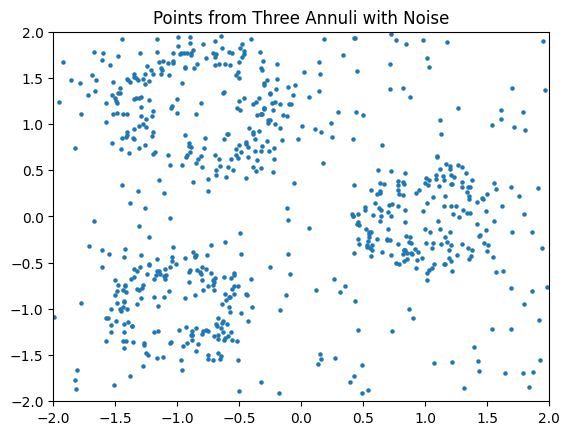

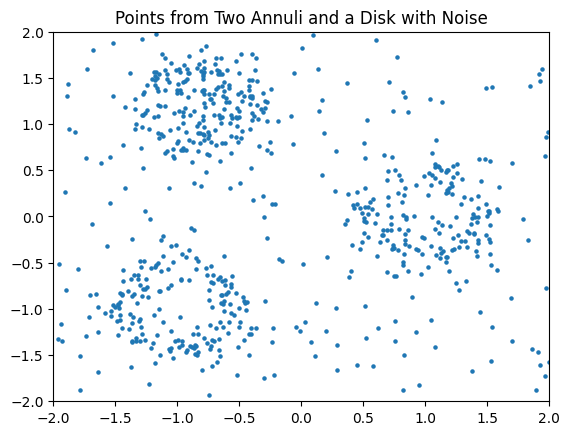

In [ ]:



def sample_annulus(n_points, r_inner, r_outer, noise=0.0, center=(0,0)):
    """
    Sample points uniformly from an annulus with inner radius r_inner and outer radius r_outer.
    Optionally add Gaussian noise.
    """
    theta = np.random.uniform(0, 2*np.pi, n_points)
    r = np.sqrt(np.random.uniform(r_inner**2, r_outer**2, n_points))
    x = center[0] + r * np.cos(theta)
    y = center[1] + r * np.sin(theta)
    points = np.column_stack([x, y])

    if noise > 0:
        points += np.random.normal(scale=noise, size=points.shape)

    return points

def sample_disk(n_points, radius, noise=0.0, center=(0,0)):
    """
    Sample points uniformly from a disk with given radius.
    Optionally add Gaussian noise.
    """
    theta = np.random.uniform(0, 2*np.pi, n_points)
    r = np.sqrt(np.random.uniform(0, radius**2, n_points))
    x = center[0] + r * np.cos(theta)
    y = center[1] + r * np.sin(theta)
    points = np.column_stack([x, y])

    if noise > 0:
        points += np.random.normal(scale=noise, size=points.shape)

    return points



def generate_three_annuli(n, r11, r12, r21, r22, r31, r32, noise=0.05):

    anti_noise_prop=0.7
    area1=(np.pi*(r12**2-r11**2))
    area2=(np.pi*(r22**2-r21**2))
    area3=(np.pi*(r32**2-r31**2))
    total_area=area1+area2+area3
    n1 = int(n*anti_noise_prop*area1/total_area)
    n2 = int(n*anti_noise_prop*area2/total_area)
    n3= int(n*anti_noise_prop*area3/total_area)
    n_noise=n-n1-n2-n3

    #print(n1, n2, n3, n_noise)
    # Annulus 1 (centered at origin)
    annulus1 = sample_annulus(n1, r_inner=r11, r_outer=r12, noise=noise, center=(-1,-1))

    # Annulus 2 (shifted so it does not overlap)
    annulus2 = sample_annulus(n2, r_inner=r21, r_outer=r22, noise=noise, center=(1,0))

    # Disk (shifted so it does not overlap)
    annulus3= sample_annulus(n3, r_inner=r31, r_outer=r32, noise=noise, center=(-0.8,1.2))
    more_noise= np.random.uniform(low=-2, high=2, size=(n_noise,2))
    # Combine all points
    return np.vstack([annulus1, annulus2, annulus3, more_noise])


points_2 = generate_three_annuli(700,0.3,0.55, 0.3, 0.55, 0.45, 0.7, noise=0.10)
plt.scatter(points_2[:,0], points_2[:,1], s=5)
plt.axis([-2,2,-2,2])
plt.title("Points from Three Annuli with Noise")
plt.show()



def generate_two_annuli_and_disk(n, r11,r12,r21, r22,r3,noise=0.05):

    anti_noise_prop=0.7
    area1=(np.pi*(r12**2-r11**2))
    area2=(np.pi*(r22**2-r21**2))
    area3=(np.pi*(r3**2))
    total_area=area1+area2+area3
    n1 = int(n*anti_noise_prop*area1/total_area)
    n2 = int(n*anti_noise_prop*area2/total_area)
    n_disk = int(n*anti_noise_prop*area3/total_area)
    n_noise=n-n1-n2-n_disk
    #print(n1, n2, n_disk, n_noise)
    # Annulus 1 (centered at origin)
    annulus1 = sample_annulus(n1, r_inner=r11, r_outer=r12, noise=noise, center=(-1,-1))

    # Annulus 2 (shifted so it does not overlap)
    annulus2 = sample_annulus(n2, r_inner=r21, r_outer=r22, noise=noise, center=(1,0))

    # Disk (shifted so it does not overlap)
    disk_points = sample_disk(n_disk, radius=r3, noise=noise, center=(-0.8,1.2))
    more_noise= np.random.uniform(low=-2, high=2, size=(n_noise,2))
    # Combine all points
    return np.vstack([annulus1, annulus2, disk_points, more_noise])


points_1 = generate_two_annuli_and_disk(700,0.3,0.55, 0.3, 0.55, 0.536, noise=0.10)


plt.scatter(points_1[:,0], points_1[:,1], s=5)
plt.axis([-2,2,-2,2])
plt.title("Points from Two Annuli and a Disk with Noise")
plt.show()




Support Vector Machine Classification using Landscapes VS. MPHvect

We will attempt two methods of discerning between data sets from either of the sampling methods above.
First we will attempt 1-parameter persistence, and compute the persistence landscapes for homology in degree 1. We will then attempt to discern between landscapes derived from a 3-Annulus sampling and those derived from a 2-Annulus+Disk sampling. For our experiment, we use Support Vector Machine to attempt this classification.

In [ ]:
# Here we generate 100 samplings of two classes of data. Each sampling of the first class consists of points sampled from 3 annuli, with random noise added in.
# Each sampling in the second class consists of points sampled from 2 annuli and one disc, with random noise added. (Both classes illustrated above)
iterations=100
number_of_points=700
Class_Annulus=[]
Class_Disc=[]

for i in range(iterations):
  np.random.seed(i)
  double_points=generate_two_annuli_and_disk(number_of_points,0.3,0.55, 0.3,0.55, 0.536, noise=0.2)

  Class_Disc.append(double_points)


  triple_points = generate_three_annuli(number_of_points,0.3,0.55, 0.3, 0.55, 0.45, 0.7, noise=0.2)
  Class_Annulus.append(triple_points)

  sys.stdout.write(f"\rCompleted {i+1}/{iterations}")
  sys.stdout.flush()
print()

Completed 100/100


Testing SVM Classification of 1-Parameter Persistence and Persistence Landscapes

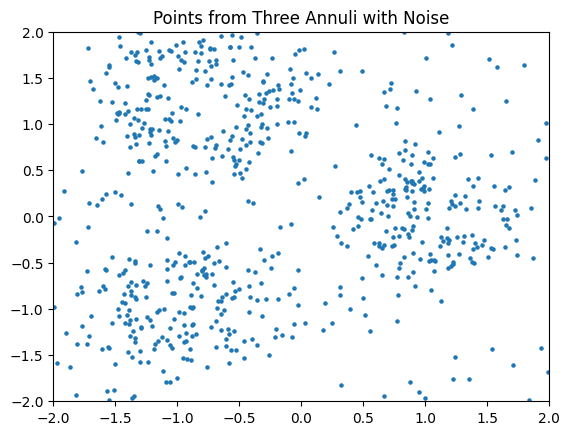

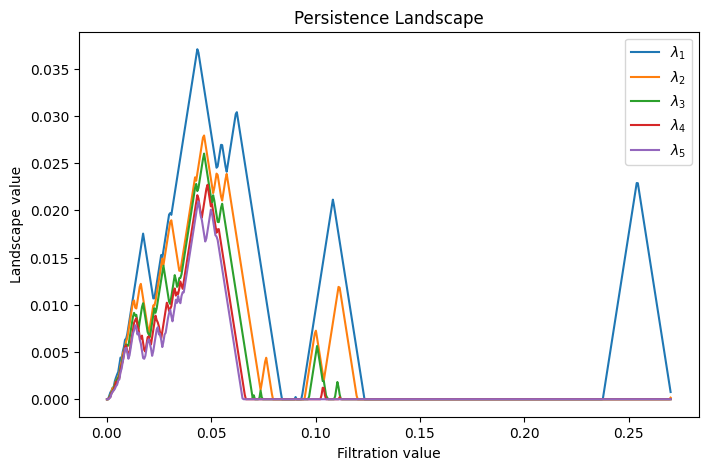

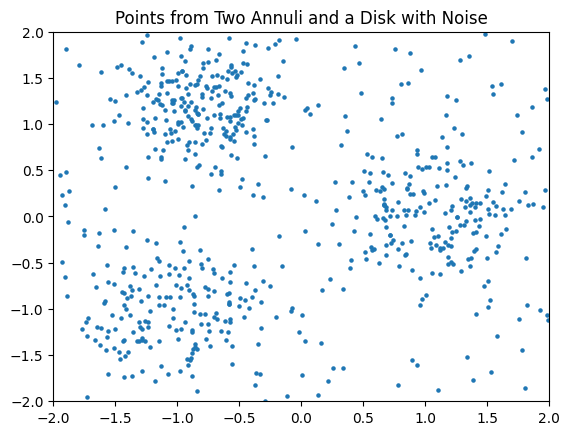

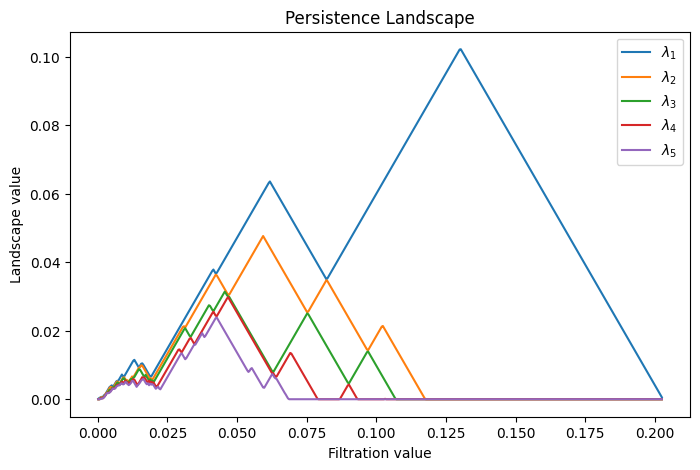

In [ ]:
#Below we illustrate a persistence landscape for one data set of each of the two sampling methods

points=Class_Annulus[0]

plt.scatter(points[:,0], points[:,1], s=5)
plt.axis([-2,2,-2,2])
plt.title("Points from Three Annuli with Noise")
plt.show()

alpha = gd.AlphaComplex(points=points)
st = alpha.create_simplex_tree()
st.persistence()
H1 = st.persistence_intervals_in_dimension(1)


landscape = Landscape(resolution=500, num_landscapes=5)
L = landscape.fit_transform([H1])[0]
L = L.reshape(5, 500)
bmin = H1[:,0].min()
dmax = H1[:,1].max()
t = np.linspace(bmin, dmax, 500)

plt.figure(figsize=(8,5))
for k in range(5):
    plt.plot(t, L[k], label=f"$\lambda_{k+1}$")

plt.xlabel("Filtration value")
plt.ylabel("Landscape value")
plt.title("Persistence Landscape")
plt.legend()
plt.show()


points=Class_Disc[0]

plt.scatter(points[:,0], points[:,1], s=5)
plt.axis([-2,2,-2,2])
plt.title("Points from Two Annuli and a Disk with Noise")
plt.show()

alpha = gd.AlphaComplex(points=points)
st = alpha.create_simplex_tree()
st.persistence()
H1 = st.persistence_intervals_in_dimension(1)


landscape = Landscape(resolution=500, num_landscapes=5)
L = landscape.fit_transform([H1])[0]
L = L.reshape(5, 500)
bmin = H1[:,0].min()
dmax = H1[:,1].max()
t = np.linspace(bmin, dmax, 500)

plt.figure(figsize=(8,5))
for k in range(5):
    plt.plot(t, L[k], label=f"$\lambda_{k+1}$")

plt.xlabel("Filtration value")
plt.ylabel("Landscape value")
plt.title("Persistence Landscape")
plt.legend()
plt.show()



In [ ]:
#We now compute the persistence landscape for each of the 200 samplings that we used before.


def compute_landscapes(points, num_layers=5, dmax=0.3, resolution=500):
  alpha = gd.AlphaComplex(points=points)
  st = alpha.create_simplex_tree()

  st.persistence()


  H1 = st.persistence_intervals_in_dimension(1)


  landscape=PersLandscapeApprox(dgms=[H1], hom_deg=0, start=0, stop=dmax, num_steps=resolution).values
  flat_landscape=landscape[:num_layers].flatten()
  return flat_landscape



Landscape_Ann=[]
Landscape_Dis=[]
for i in range(iterations):
  points=Class_Annulus[i]
  Landscape_Ann.append(compute_landscapes(points))

  points=Class_Disc[i]
  Landscape_Dis.append(compute_landscapes(points))

  sys.stdout.write(f"\rCompleted {i+1}/{iterations}")
  sys.stdout.flush()
print()

Completed 100/100


Below we plot the average persistence landscape of each class, as well as the difference of the two averages


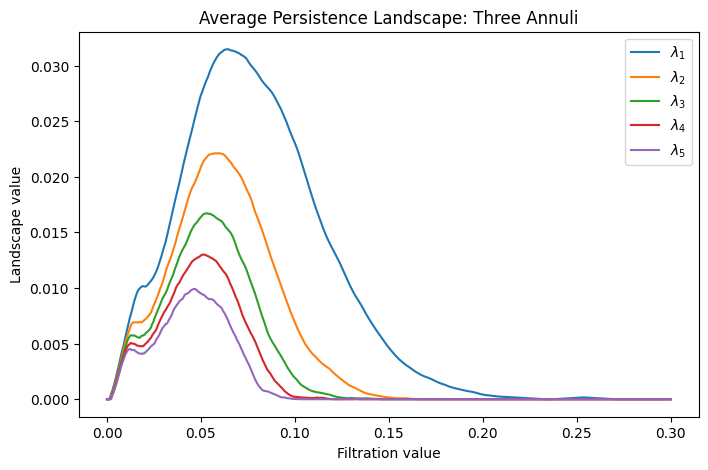

(100, 2500)


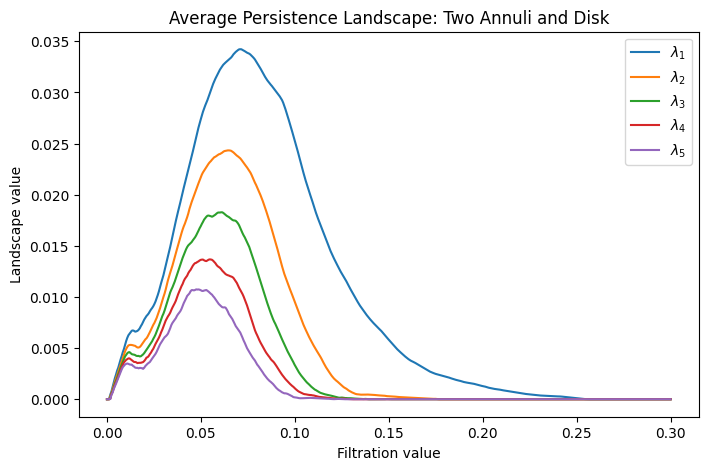

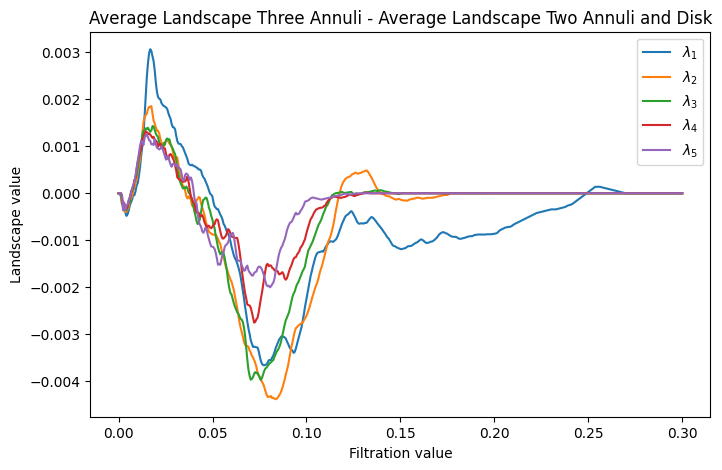

In [ ]:
L_Ann_stack = np.vstack(Landscape_Ann)   # shape: (50, D)
L_Ann_avg_flat = L_Ann_stack.mean(axis=0)      # shape: (D,)
L_Ann_avg = L_Ann_avg_flat.reshape(5, 500)

# Manual domain
bmin=0
dmax=0.3
t = np.linspace(bmin, dmax, 500)

plt.figure(figsize=(8,5))
for k in range(5):
    plt.plot(t, L_Ann_avg[k], label=f"$\lambda_{k+1}$")

plt.xlabel("Filtration value")
plt.ylabel("Landscape value")
plt.title("Average Persistence Landscape: Three Annuli")
plt.legend()
plt.show()



L_Dis_stack = np.vstack(Landscape_Dis)
print(L_Dis_stack.shape)  # shape: (50, D)
L_Dis_avg_flat = L_Dis_stack.mean(axis=0)      # shape: (D,)

L_Dis_avg = L_Dis_avg_flat.reshape(5, 500)





plt.figure(figsize=(8,5))
for k in range(5):
    plt.plot(t, L_Dis_avg[k], label=f"$\lambda_{k+1}$")

plt.xlabel("Filtration value")
plt.ylabel("Landscape value")
plt.title("Average Persistence Landscape: Two Annuli and Disk")
plt.legend()
plt.show()

L_dif=L_Ann_avg-L_Dis_avg



plt.figure(figsize=(8,5))
for k in range(5):
    plt.plot(t, L_dif[k], label=f"$\lambda_{k+1}$")

plt.xlabel("Filtration value")
plt.ylabel("Landscape value")
plt.title("Average Landscape Three Annuli - Average Landscape Two Annuli and Disk")
plt.legend()
plt.show()


Observed accuracy: 0.5600
Permutation p-value: 0.0100


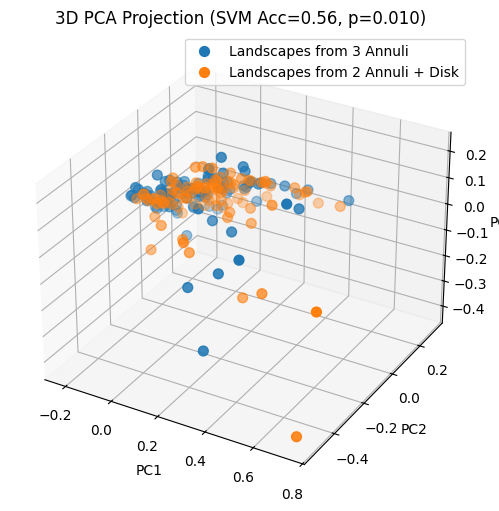

In [ ]:
# Here we perform a support vector machine classification test on these 200 vectors of size (2500,) representing the 200 persistence landscapes.
# We also perform a permutation test with 1000 permutations to determine a p-value.
# We finally plot the projection into 3 dimensions using principle component analysis.

do_SVM_and_PCA(Landscape_Ann, Landscape_Dis, name_1='Landscapes from 3 Annuli', name_2='Landscapes from 2 Annuli + Disk')

We now consider an alternate method of using TDA to discern between these two kinds of samplings. We first use signed rectangle barcodes (Magnus Botnan, Stephen Opperman, Steve Oudot, 2024) using the Multipers package by David Loiseaux and Hannah Schreiber.

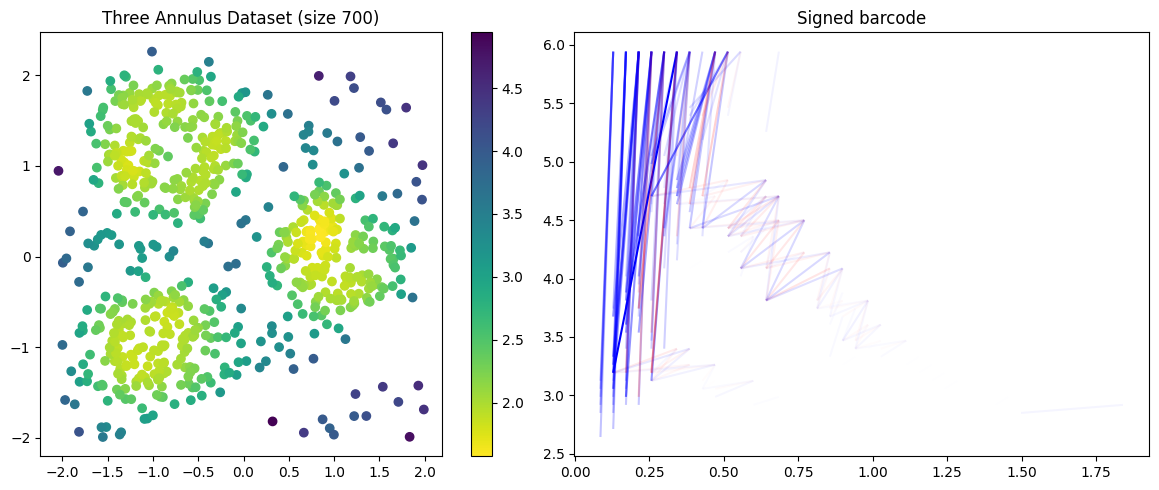

In [ ]:
#The following is script from the Multipers github page for calcluating and plotting signed rectangle barcodes.
#In this setting, we consider the density-rips bifiltration on the data set, yielding a bi-persistence module on the poset R^2. The signed rectangle barcode of this module is a collection of rectangles in R^2 with positive and negative multiplicities.
#To avoid an overly cluttered visual of these rectangles, Botnan, Opperman and Oudot only plot the diagonals of these rectangles.
#Rectangles with very small width or very small height are considered to come from less significant features, similar to how points close to the diagonal in 1-parameter persistence are considered insignificant.

#First we look at the signed barcode for a bi-module generated on a data set of points sampled from 3 annuli with noise

points=Class_Annulus[0]

#we will generate a bi-filtration of simplicial complexes on the data sets of these two sampling methods using a density-rips filtration.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


kde = KernelDensity(kernel="gaussian", bandwidth=0.2).fit(points)
density = kde.score_samples(points)

sc = axes[0].scatter(*points.T, c=-density, cmap="viridis_r")
axes[0].set_aspect(1)
axes[0].set_title(f"Three Annulus Dataset (size {points.shape[0]})")
fig.colorbar(sc, ax=axes[0])


simplextree = RipsLowerstar(points=points, function=1 - density, threshold_radius=2.5)
simplextree.collapse_edges(-2)
simplextree.expansion(2)
simplextree.prune_above_dimension(2)

grid = mp.grids.compute_grid(
    simplextree,
    strategy="regular",
    resolution=50,
)


rank_sm = mp.signed_measure(
    simplextree.grid_squeeze(grid),
    degree=1,
    invariant="rank",
    plot=True,
    ax=axes[1],
)

axes[1].set_title("Signed barcode")

plt.tight_layout()
plt.show()


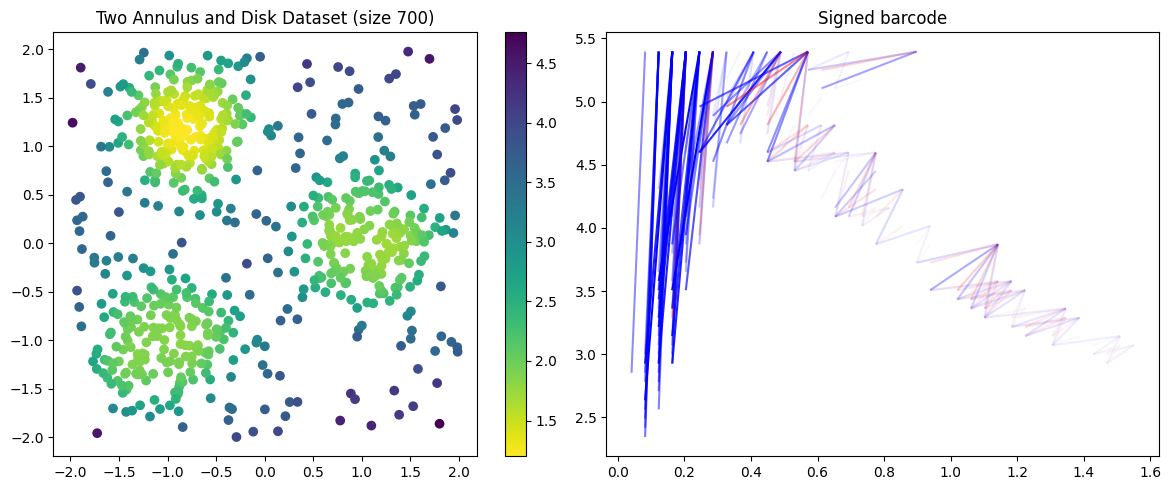

In [ ]:
#Now let's look at the signed barcode for such a bimodule generated on a data set from two annuli and a disk with noise.

points = Class_Disc[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


kde = KernelDensity(kernel="gaussian", bandwidth=0.2).fit(points)
density = kde.score_samples(points)

sc = axes[0].scatter(*points.T, c=-density, cmap="viridis_r")
axes[0].set_aspect(1)
axes[0].set_title(f"Two Annulus and Disk Dataset (size {points.shape[0]})")
fig.colorbar(sc, ax=axes[0])


simplextree = RipsLowerstar(points=points, function=1 - density, threshold_radius=2.5)
simplextree.collapse_edges(-2)
simplextree.expansion(2)
simplextree.prune_above_dimension(2)

grid = mp.grids.compute_grid(
    simplextree,
    strategy="regular",
    resolution=50,
)


rank_sm = mp.signed_measure(
    simplextree.grid_squeeze(grid),
    degree=1,
    invariant="rank",
    plot=True,
    ax=axes[1],
)

axes[1].set_title("Signed barcode")

plt.tight_layout()
plt.show()



In [ ]:
#We now compute signed barcodes for each of the data sets we generated previously



Triple_Annulus_barcodes=[]
for i, points in enumerate(Class_Annulus):
  kde = KernelDensity(kernel="gaussian", bandwidth=0.2).fit(points)
  density = kde.score_samples(points)
  simplextree = RipsLowerstar(points=points, function = 1-density, threshold_radius=0.5)
  simplextree.collapse_edges(-2)
  simplextree.expansion(2)
  simplextree.prune_above_dimension(2)
  grid = mp.grids.compute_grid(
      simplextree,
      strategy="regular",
      resolution=50,
  )
  rank_sm = mp.signed_measure(
      simplextree.grid_squeeze(grid),
      degree=1,
      invariant = "rank",
      plot = False,
  );
  Triple_Annulus_barcodes.append(rank_sm[0])
  sys.stdout.write(f"\rCompleted {i+1}/{iterations}")
  sys.stdout.flush()

print()




Double_Annulus_Disk_barcodes=[]
for i, points in enumerate(Class_Disc):
  kde = KernelDensity(kernel="gaussian", bandwidth=0.2).fit(points)
  density = kde.score_samples(points)
  simplextree = RipsLowerstar(points=points, function = 1-density, threshold_radius=0.75)
  simplextree.collapse_edges(-2)
  simplextree.expansion(2)
  simplextree.prune_above_dimension(2)
  grid = mp.grids.compute_grid(
      simplextree,
      strategy="regular",
      resolution=50,
  )
  rank_sm = mp.signed_measure(
      simplextree.grid_squeeze(grid),
      degree=1,
      invariant = "rank",
      plot = False,
  );
  Double_Annulus_Disk_barcodes.append(rank_sm[0])
  sys.stdout.write(f"\rCompleted {i+1}/{iterations}")
  sys.stdout.flush()

print()

Completed 100/100
Completed 100/100


In [ ]:
#We now will normalize these barcodes to fit inside the unit 4D cube.
#While we could do this with a single value in all coordinates, we found it more effective to normalize the height and width separately.
#To do this, we look at rectangles with the greatest (min(height, width)), up to some cutoff. Then we look at the maximum y-value and maximum x-value of these rectangles in the collection of barcodes.
#We normalize the height and width of all the rectangles of all the barcodes by these values.




Annulus_height, Annulus_width=get_4d_norm_vals(Triple_Annulus_barcodes, cutoff=50)
Disk_height, Disk_width= get_4d_norm_vals(Double_Annulus_Disk_barcodes, cutoff=50)

height=max(Annulus_height, Disk_height)
width=max(Annulus_width, Disk_width)

scale=np.array([width, height, width, height])

for i,b in enumerate(Triple_Annulus_barcodes):
    bars,mults=b
    penultimate_bars=0.9*bars/scale
    normed_bars=replace_inf_safe(penultimate_bars)

    Triple_Annulus_barcodes[i]=(normed_bars,mults)
    sys.stdout.write(f"\rCompleted {i+1}/{iterations}")
    sys.stdout.flush()
print()

for i,b in enumerate(Double_Annulus_Disk_barcodes):
    bars,mults=b
    penultimate_bars=0.9*bars/scale
    normed_bars=replace_inf_safe(penultimate_bars)

    Double_Annulus_Disk_barcodes[i]=(normed_bars,mults)
    sys.stdout.write(f"\rCompleted {i+1}/{iterations}")
    sys.stdout.flush()
print()


get_4d_norm_vals(Triple_Annulus_barcodes)
get_4d_norm_vals(Double_Annulus_Disk_barcodes)

Completed 100/100
Completed 100/100


(np.float64(1.0), np.float64(1.0))

In [ ]:
# Now map each of these normalized barcodes to a vector using MPHvect.
# The theory behind MPHvect uses a Schauder basis of functionals on the unit 4D cube, generated by a nested sequence of infinitely many triangulations.
# We first generate indexing lists to determine how many of these triangulations we will use in our experiment. This is done using collect_vertices(dim, max_layer, min_layer=0).
# The first parameter dim is the number of parameters of the persistence modules you are working with (2 in this case).
# The second parameter, max_layer, indicates how many refinements of the Coxeter Freudenthal Kuhn triangulation will use to generate our vectorizing subset of functionals in the Schauder Basis.
# For visualizations, it is sometimes useful to skip the first few refinements of this triangulation. That is what the min_layer parameter is there for.


n_list, p_list=collect_vertices(dim=2, max_layer=3)
print("List Generated")



Triple_Annulus_vectors=[]
for i,barcode in enumerate(Triple_Annulus_barcodes):
  Triple_Annulus_vectors.append(vectorize_fast(n_list, p_list, barcode[0], barcode[1]))
  sys.stdout.write(f"\rCompleted {i+1}/{iterations}")
  sys.stdout.flush()
print()

Annulus_Disk_vectors=[]
for i,barcode in enumerate(Double_Annulus_Disk_barcodes):
  Annulus_Disk_vectors.append(vectorize_fast(n_list, p_list, barcode[0], barcode[1]))
  sys.stdout.write(f"\rCompleted {i+1}/{iterations}")
  sys.stdout.flush()
print()



List Generated
Completed 100/100
Completed 100/100


Observed accuracy: 1.0000
Permutation p-value: 0.0000


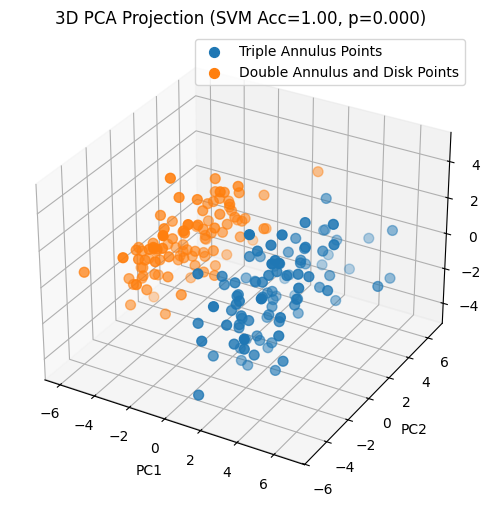

In [ ]:
do_SVM_and_PCA(Triple_Annulus_vectors, Annulus_Disk_vectors, name_1="Triple Annulus Points", name_2="Double Annulus and Disk Points")

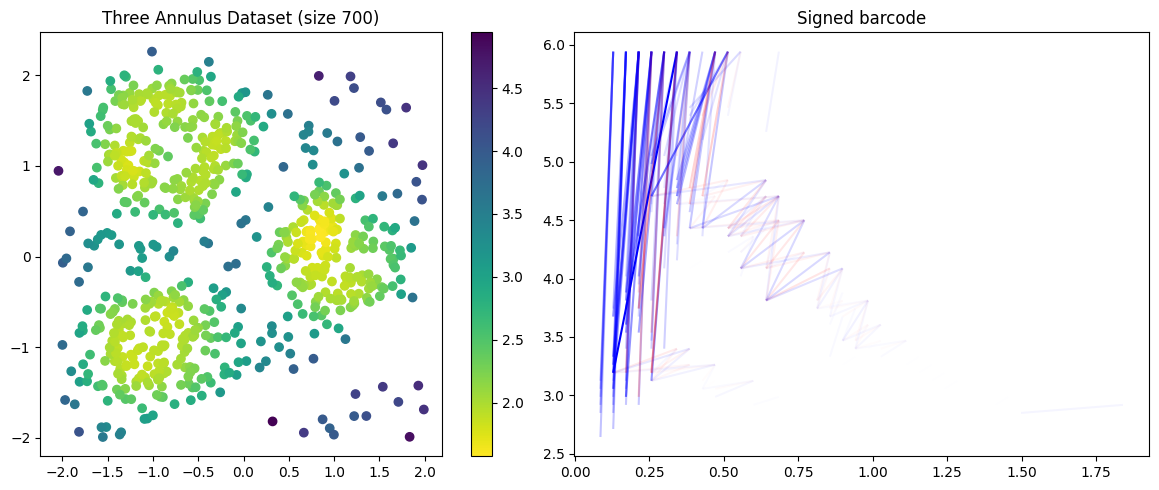

In [ ]:
#We may visualize the resulting vector of a signed barcode through towers of color coded rectangles in R^3.
#Below, we look at the first sampling of the data sets sampled from three annuli. For visualization, we treat each rectangle as a barcode, and apply our method.
#That is, we yield a vector for each bar of the barcode instead of one vector for the entire barcode.
#For each bar (diagonal), we plot rectangles in the positive or negative z direction, with heights equal to the values in that resulting vector of that bar (diagonal).
#The resulting figure below illustrates that our method assigns bars of small height or small width a vector of small magnitude relative to other bars.


points=Class_Annulus[0]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


kde = KernelDensity(kernel="gaussian", bandwidth=0.2).fit(points)
density = kde.score_samples(points)

sc = axes[0].scatter(*points.T, c=-density, cmap="viridis_r")
axes[0].set_aspect(1)
axes[0].set_title(f"Three Annulus Dataset (size {points.shape[0]})")
fig.colorbar(sc, ax=axes[0])


simplextree = RipsLowerstar(points=points, function=1 - density, threshold_radius=2.5)
simplextree.collapse_edges(-2)
simplextree.expansion(2)
simplextree.prune_above_dimension(2)

grid = mp.grids.compute_grid(
    simplextree,
    strategy="regular",
    resolution=50,
)


rank_sm = mp.signed_measure(
    simplextree.grid_squeeze(grid),
    degree=1,
    invariant="rank",
    plot=True,
    ax=axes[1],
)

axes[1].set_title("Signed barcode")

plt.tight_layout()
plt.show()



MPHvect_nailbed(Triple_Annulus_barcodes[0][0], multiplicities =Triple_Annulus_barcodes[0][1], number_of_triangulations=2)